# IM-DD Optical Access Link — Trade-off Study
**OOK vs 4-PAM under varying received power, receiver bandwidth, fiber length, and dispersion**

This notebook runs all simulations and produces all figures for the thesis.  
All signal processing logic lives in `imdd_lib.py` — this file only sets parameters and calls functions.

---
**Structure**
1. Setup
2. Global simulation parameters
3. Single-run sanity check + eye diagrams
4. Sweep 1 — BER vs Received Power (OOK vs PAM4)
5. Sweep 2 — BER vs Receiver Bandwidth (OOK vs PAM4)
6. Sweep 3 — BER vs Fiber Length (OOK vs PAM4)
7. Sweep 4 — BER vs Fiber Dispersion (OOK vs PAM4)
8. Trade-off summary table

---
## 1. Setup

In [3]:
# Install OptiCommPy if running on Google Colab
import sys
if 'google.colab' in sys.modules:
    import subprocess
    subprocess.run(['git', 'clone', '-b', 'main', 'https://github.com/edsonportosilva/OptiCommPy'])
    import os; os.chdir('/content/OptiCommPy/')
    subprocess.run(['pip', 'install', '.'])

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.core.pylabtools import figsize
from IPython.core.display import HTML

from imdd_lib import (
    run_link,
    sweep_ber_vs_power,
    sweep_ber_vs_bandwidth,
    sweep_ber_vs_fiber_length,
    sweep_ber_vs_dispersion,
    plot_eye_diagrams,
    plot_ber_vs_power,
    plot_ber_vs_bandwidth,
    plot_ber_vs_length,
    plot_ber_vs_dispersion,
    print_summary,
)

figsize(10, 3)
HTML("""
<style>
.output_png { display: table-cell; text-align: center; vertical-align: middle; }
</style>
""")

---
## 2. Global Simulation Parameters

All shared parameters are defined here.  
Sweep-specific overrides are set locally in each sweep section.

In [5]:
# ── Simulation resolution ────────────────────────────────────────────────────
SpS    = 16        # samples per symbol
nBits  = 100_000   # bits per simulation run (increase for lower BER floor)

# ── Signal parameters ────────────────────────────────────────────────────────
Rs     = 10e9      # symbol rate [Hz]  →  10 Gbaud
Rs_4PAM = Rs/2

# ── Fiber parameters (defaults — overridden per sweep) ───────────────────────
FIBER_L     = 10   # fiber length [km]
FIBER_ALPHA = 0.2  # attenuation [dB/km]
FIBER_D     = 16   # dispersion  [ps/nm/km]
Fc          = 193.1e12  # central optical frequency [Hz]

# ── Receiver parameters (defaults) ───────────────────────────────────────────
RX_BW = Rs         # matched-filter bandwidth (B = Rs)
RX_BW_4PAM = Rs/2

# ── BER target reference line ────────────────────────────────────────────────
BER_TARGET = 1e-3  # choose FEC threshold for access links

print(f"Symbol rate OOK   : {Rs/1e9:.0f} Gbaud")
print(f"Symbol rate 4-PAM : {Rs_4PAM/1e9:.0f} Gbaud")
print(f"Bit rate OOK      : {Rs/1e9:.0f} Gb/s")
print(f"Bit rate PAM4     : {2*Rs_4PAM/1e9:.0f} Gb/s")
print(f"Fiber             : {FIBER_L} km, α={FIBER_ALPHA} dB/km, D={FIBER_D} ps/nm/km")

Symbol rate OOK   : 10 Gbaud
Symbol rate 4-PAM : 5 Gbaud
Bit rate OOK      : 10 Gb/s
Bit rate PAM4     : 10 Gb/s
Fiber             : 10 km, α=0.2 dB/km, D=16 ps/nm/km


---
## 3. Single-Run Sanity Check + Eye Diagrams

Verify the link works correctly before running sweeps.  
Inspect eye diagrams at Tx and Rx for both modulation formats.

In [6]:
# ── OOK single run ───────────────────────────────────────────────────────────
Pi_test = -10  # [dBm] — choose a power level with expected BER > 0

res_ook = run_link(
    Pi_dBm       = Pi_test,
    M            = 2,
    SpS          = SpS,
    Rs           = Rs,
    fiber_L      = FIBER_L,
    fiber_alpha  = FIBER_ALPHA,
    fiber_D      = FIBER_D,
    Fc           = Fc,
    rx_bandwidth = RX_BW,
    rx_ideal     = False,
    nBits        = nBits,
    seed         = 12335,
)

print("=== OOK single run ===")
print_summary(res_ook)

=== OOK single run ===
  Modulation : M=2 (OOK)
  Pi_dBm     : -10.0 dBm
  Symbol rate: 10.0 Gbaud
  Q-factor   : 13.17
  BER (sim)  : 0.00e+00
  Pb (theory): 6.37e-40


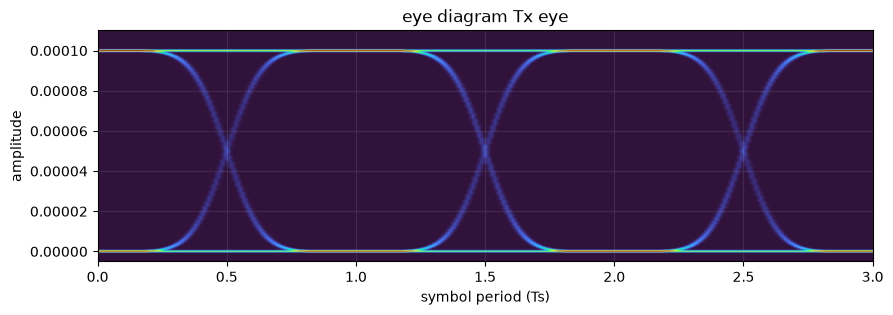

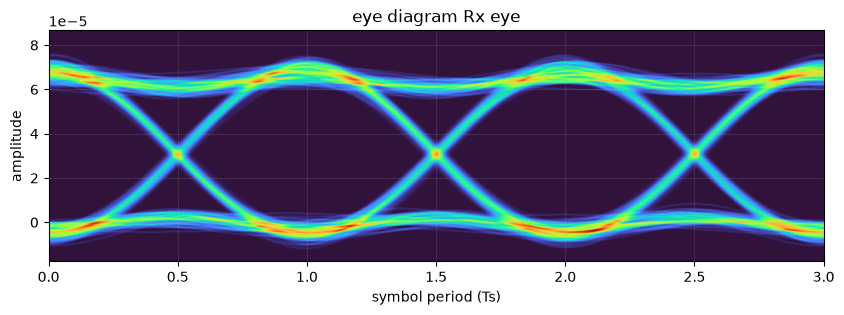

In [7]:
# Eye diagrams — OOK
plot_eye_diagrams(res_ook, discard=50)

In [8]:
# ── PAM4 single run ──────────────────────────────────────────────────────────
res_pam4 = run_link(
     Pi_dBm       = Pi_test,
     M            = 4,
     SpS          = SpS,
     Rs           = Rs_4PAM,
     fiber_L      = FIBER_L,
     fiber_alpha  = FIBER_ALPHA,
     fiber_D      = FIBER_D,
     Fc           = Fc,
     rx_bandwidth = RX_BW_4PAM,
     rx_ideal     = False,
     nBits        = nBits,
     seed         = 12335,
)
print("=== PAM4 single run ===")
print_summary(res_pam4)

=== PAM4 single run ===
  Modulation : M=4 (PAM4)
  Pi_dBm     : -10.0 dBm
  Symbol rate: 5.0 Gbaud
  Q-factor   : 5.05
  BER (sim)  : 0.00e+00
  Pb (theory): 1.66e-07


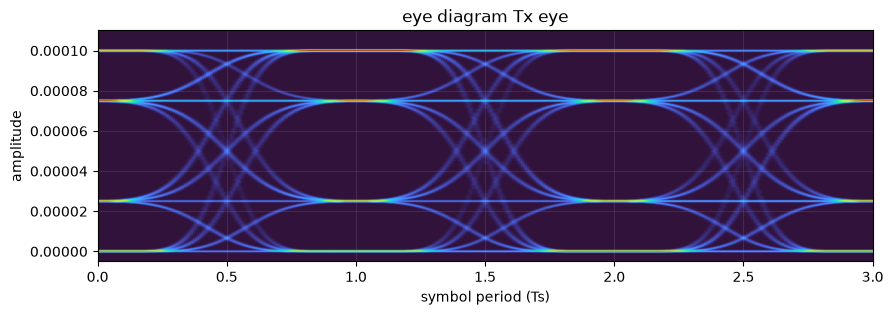

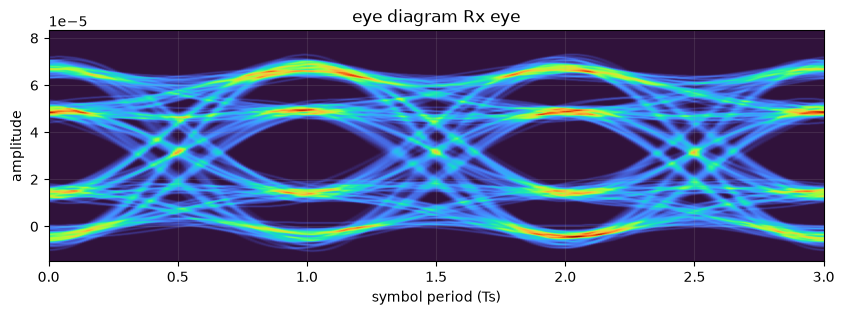

In [9]:
#  Eye diagrams — 4PAM
plot_eye_diagrams(res_pam4, discard=50)

---
## 4. Sweep 1 — BER vs Received Power

**Fixed:** fiber length, receiver bandwidth  
**Swept:** input power `Pi_dBm` → maps directly to received power after fiber loss  
**Goal:** find the power penalty of PAM4 vs OOK at BER = 10⁻³

In [10]:
power_range = np.arange(-30, -10, 1)  # [dBm]

# OOK
sweep1_ook = sweep_ber_vs_power(
    power_range  = power_range,
    M            = 2,
    Rs           = Rs,
    SpS          = SpS,
    fiber_L      = FIBER_L,
    fiber_alpha  = FIBER_ALPHA,
    fiber_D      = FIBER_D,
    Fc           = Fc,
    rx_bandwidth = RX_BW,
    nBits        = nBits,
)

# PAM4
sweep1_pam4 = sweep_ber_vs_power(
     power_range  = power_range,
     M            = 4,
     Rs           = Rs_4PAM,
     SpS          = SpS,
     fiber_L      = FIBER_L,
     fiber_alpha  = FIBER_ALPHA,
     fiber_D      = FIBER_D,
     Fc           = Fc,
     rx_bandwidth = RX_BW_4PAM,
     nBits        = nBits,
)

Sweep: power: 100%|██████████| 20/20 [00:13<00:00,  1.46it/s]


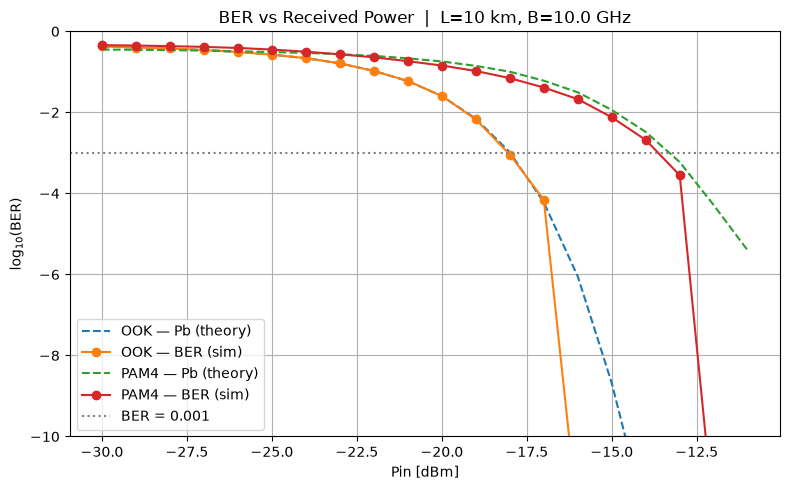

In [11]:
plot_ber_vs_power(
    results_list = [sweep1_ook, sweep1_pam4],
    labels       = ['OOK', 'PAM4'],
    title        = f'BER vs Received Power  |  L={FIBER_L} km, B={RX_BW/1e9:.1f} GHz',
    target_BER   = BER_TARGET,
)

---
## 5. Sweep 2 — BER vs Receiver Bandwidth

**Fixed:** transmit power, fiber length  
**Swept:** photodiode bandwidth `B` (normalized to `Rs`)  
**Goal:** find the optimum bandwidth and compare OOK vs PAM4 sensitivity

In [12]:
bw_range = np.linspace(0.3 * Rs, 2.0 * Rs, 30)  # [Hz]
Pi_bw    = -16  # [dBm] — fixed operating power for this sweep

# OOK
sweep2_ook = sweep_ber_vs_bandwidth(
    bw_range    = bw_range,
    Pi_dBm      = Pi_bw,
    M           = 2,
    Rs          = Rs,
    SpS         = SpS,
    fiber_L     = FIBER_L,
    fiber_alpha = FIBER_ALPHA,
    fiber_D     = FIBER_D,
    Fc          = Fc,
    nBits       = nBits,
)

sweep2_pam4 = sweep_ber_vs_bandwidth(
    bw_range    = bw_range,
    Pi_dBm      = Pi_bw,
    M           = 4,
    Rs          = Rs_4PAM,
    SpS         = SpS,
    fiber_L     = FIBER_L,
    fiber_alpha = FIBER_ALPHA,
    fiber_D     = FIBER_D,
    Fc          = Fc,
    nBits       = nBits,
)

Sweep: bandwidth: 100%|██████████| 30/30 [00:23<00:00,  1.30it/s]


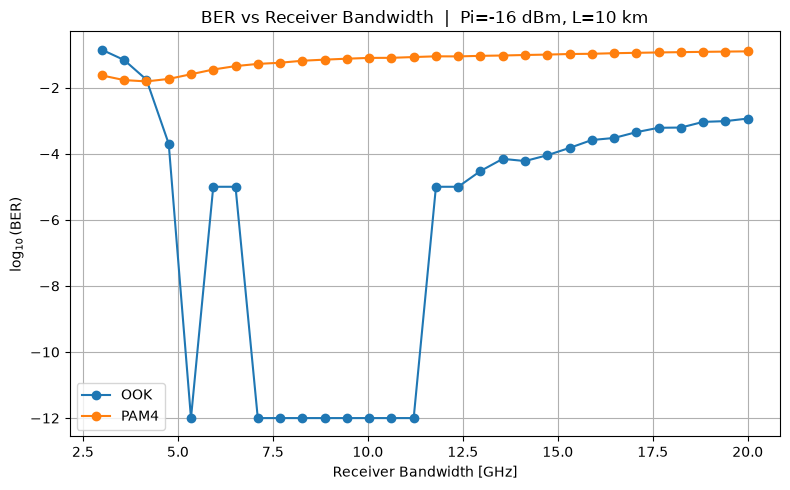

In [13]:
plot_ber_vs_bandwidth(
    results_list = [sweep2_ook, sweep2_pam4],
    labels       = ['OOK', 'PAM4'],
    title        = f'BER vs Receiver Bandwidth  |  Pi={Pi_bw} dBm, L={FIBER_L} km',
)

---
## 6. Sweep 3 — BER vs Fiber Length

**Fixed:** transmit power, receiver bandwidth  
**Swept:** fiber length `L`  
**Goal:** determine the maximum reach for each modulation at BER = 10⁻³

In [14]:
length_range = np.arange(0, 85, 5)   # [km]
Pi_len       = -10  # [dBm] — fixed transmit power for this sweep

# OOK
sweep3_ook = sweep_ber_vs_fiber_length(
    length_range = length_range,
    Pi_dBm       = Pi_len,
    M            = 2,
    Rs           = Rs,
    SpS          = SpS,
    fiber_alpha  = FIBER_ALPHA,
    fiber_D      = FIBER_D,
    Fc           = Fc,
    rx_bandwidth = RX_BW,
    nBits        = nBits,
)

# PAM4
sweep3_pam4 = sweep_ber_vs_fiber_length(
    length_range = length_range,
    Pi_dBm       = Pi_len,
    M            = 4,
    Rs           = Rs_4PAM,
    SpS          = SpS,
    fiber_alpha  = FIBER_ALPHA,
    fiber_D      = FIBER_D,
    Fc           = Fc,
    rx_bandwidth = RX_BW,
    nBits        = nBits,
)

Sweep: fiber length: 100%|██████████| 17/17 [00:12<00:00,  1.37it/s]


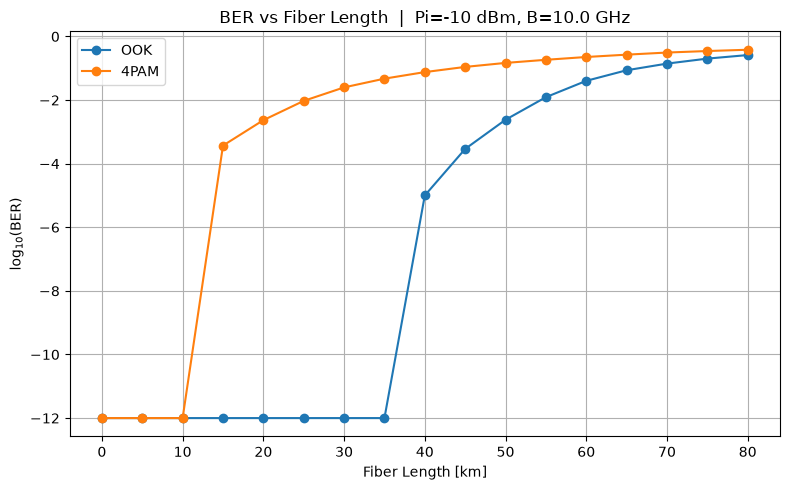

In [15]:
plot_ber_vs_length(
    results_list = [sweep3_ook, sweep3_pam4],
    labels       = ['OOK', '4PAM'],
    title        = f'BER vs Fiber Length  |  Pi={Pi_len} dBm, B={RX_BW/1e9:.1f} GHz',
)

---
## 7. Sweep 4 — BER vs Fiber Dispersion

**Fixed:** transmit power, fiber length, receiver bandwidth  
**Swept:** dispersion coefficient `D` [ps/nm/km]  
**Goal:** quantify dispersion tolerance difference between OOK and PAM4

In [16]:
dispersion_range = np.arange(0, 21, 1)  # [ps/nm/km]
Pi_disp          = -10  # [dBm]

# OOK
sweep4_ook = sweep_ber_vs_dispersion(
    dispersion_range = dispersion_range,
    Pi_dBm           = Pi_disp,
    M                = 2,
    Rs               = Rs,
    SpS              = SpS,
    fiber_L          = FIBER_L,
    fiber_alpha      = FIBER_ALPHA,
    Fc               = Fc,
    rx_bandwidth     = RX_BW,
    nBits            = nBits,
)

# PAM4
sweep4_pam4 = sweep_ber_vs_dispersion(
    dispersion_range = dispersion_range,
    Pi_dBm           = Pi_disp,
    M                = 4,
    Rs               = Rs_4PAM,
    SpS              = SpS,
    fiber_L          = FIBER_L,
    fiber_alpha      = FIBER_ALPHA,
    Fc               = Fc,
    rx_bandwidth     = RX_BW,
    nBits            = nBits,
)

Sweep: dispersion: 100%|██████████| 21/21 [00:14<00:00,  1.46it/s]


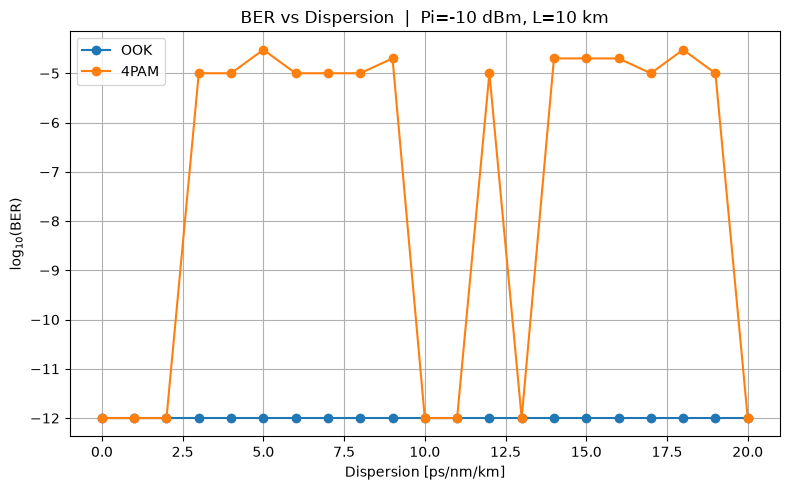

In [17]:
plot_ber_vs_dispersion(
    results_list = [sweep4_ook, sweep4_pam4],
    labels       = ['OOK', '4PAM'],
    title        = f'BER vs Dispersion  |  Pi={Pi_disp} dBm, L={FIBER_L} km',
)

---
## 8. Trade-off Summary Table

In [ ]:
# TODO: Collect key metrics from all sweeps into a single comparison table.
# def find_sensitivity(sweep_result, ber_target=1e-3):
#     """
#     Find the minimum power [dBm] at which BER <= ber_target.
#     Returns NaN if target is never reached within the sweep range.
#     """
#     power = sweep_result['power']
#     ber   = sweep_result['BER']
#     mask  = ber <= ber_target
#     return float(power[mask][0]) if mask.any() else float('nan')
#
#
# def find_max_reach(sweep_result, ber_target=1e-3):
#     """
#     Find the maximum fiber length [km] at which BER <= ber_target.
#     Returns NaN if target is never met.
#     """
#     length = sweep_result['length']
#     ber    = sweep_result['BER']
#     mask   = ber <= ber_target
#     return float(length[mask][-1]) if mask.any() else float('nan')
#
#
# def find_opt_bandwidth(sweep_result):
#     """
#     Find the receiver bandwidth [Hz] that minimizes BER.
#     """
#     bw  = sweep_result['bandwidth']
#     ber = sweep_result['BER']
#     return float(bw[np.argmin(ber)])
#
#
# # ── Build summary ─────────────────────────────────────────────────────────────
# sensitivity_ook  = find_sensitivity(sweep1_ook,  BER_TARGET)
# max_reach_ook    = find_max_reach(sweep3_ook,     BER_TARGET)
# opt_bw_ook       = find_opt_bandwidth(sweep2_ook)
#
# # Replace with real values once PAM4 is implemented
# sensitivity_pam4 = float('nan')
# max_reach_pam4   = float('nan')
# opt_bw_pam4      = float('nan')
#
# summary = pd.DataFrame({
#     'Metric'                     : [
#         f'Sensitivity @ BER={BER_TARGET} [dBm]',
#         'Maximum reach [km]',
#         'Optimum Rx bandwidth [GHz]',
#         'Bit rate [Gb/s]',
#         'Spectral efficiency [b/s/Hz]',
#     ],
#     'OOK'  : [
#         f'{sensitivity_ook:.1f}',
#         f'{max_reach_ook:.0f}',
#         f'{opt_bw_ook/1e9:.2f}',
#         f'{Rs/1e9:.0f}',
#         '1.0',
#     ],
#     'PAM4' : [
#         f'{sensitivity_pam4}',   # fill after PAM4 sweep
#         f'{max_reach_pam4}',
#         f'{opt_bw_pam4}',
#         f'{2*Rs/1e9:.0f}',
#         '2.0',
#     ],
# })
#
# summary.set_index('Metric', inplace=True)
# display(summary)

In [ ]:
# Optional: export summary to CSV for inclusion in thesis
# summary.to_csv('tradeoff_summary.csv')
# print("Summary saved to tradeoff_summary.csv")